Study the convergence for different values of curvature

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

curvature h[m^-1]:  0.1 radius of curvature [m]:  10.0
E [GeV]:  1.03827208816
beta0:  0.42819548497881543
nphi= 5


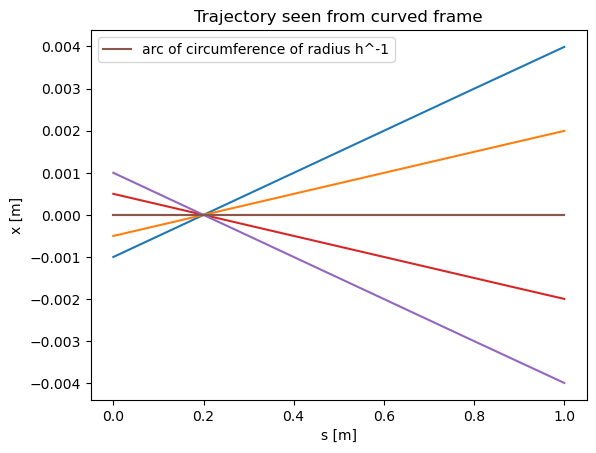

In [13]:
a_curved = [0,]
b_curved = [0.1, 0.02]
h= b_curved[0]# considering normalization B/Brho=1/rho=h            =1. if checking for a drift
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
p0 =xt.Particles(x=np.linspace(-1e-3, 1e-3, 5), y=0, s=0, py=np.linspace(0.005,-0.005,5), px=np.linspace(0.005,-0.005,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()
nphi=5
print("nphi=",nphi)
A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved, nphi=nphi)
H_curved = bpmeth.Hamiltonian(length=1, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory seen from curved frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

In [14]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=5)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  (y**3*(0.0002*x + 0.002)*(0.0024*x**4 + 0.096*x**3 + 1.44*x**2 + 9.6*x + 24.0) - 6*y*(0.02*x + 0.1)*(0.1*x + 1)**2*(0.0024*x**4 + 0.096*x**3 + 1.44*x**2 + 9.6*x + 24.0))/(6*(0.1*x + 1)**2*(0.0024*x**4 + 0.096*x**3 + 1.44*x**2 + 9.6*x + 24.0))

phi straight frame:  16.6666666666667*(0.0002*y**3*sqrt(s**2 + (x + 10.0)**2)*(9.6*sqrt(s**2 + (x + 10.0)**2) + 0.0024*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**4 + 0.096*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**3 + 1.44*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**2 - 72.0) - 6*y*(0.01*s**2 + 0.01*(x + 10.0)**2)*(0.02*sqrt(s**2 + (x + 10.0)**2) - 0.1)*(9.6*sqrt(s**2 + (x + 10.0)**2) + 0.0024*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**4 + 0.096*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**3 + 1.44*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**2 - 72.0))/((s**2 + (x + 10.0)**2)*(9.6*sqrt(s**2 + (x + 10.0)**2) + 0.0024*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**4 + 0.096*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**3 + 1.44*(sqrt(s**2 + (x + 10.0)**2) - 10.0)**2 - 72.0))

Bx straigh

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_4136/333832386.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.title("b(s) in straight frame from transformation of $\phi$")
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_4136/333832386.py:91: SyntaxWarning: invalid escape sequence '\p'
  plt.title("a(s) in straight frame from transformation of $\phi$")


phi1= -4.8e-5*s**6*sqrt(s**2 + x**2 + 20.0*x + 100.0)/(0.0024*s**6 + 0.0072*s**4*x**2 + 0.144*s**4*x + 0.72*s**4 + 0.0072*s**2*x**4 + 0.288*s**2*x**3 + 4.32*s**2*x**2 + 28.8*s**2*x + 3.5527136788005e-15*s**2*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 72.0*s**2 + 0.0024*x**6 + 0.144*x**5 + 3.6*x**4 + 48.0*x**3 + 3.5527136788005e-15*x**2*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 360.0*x**2 + 7.105427357601e-14*x*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 1440.0*x + 3.5527136788005e-13*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 2400.0) + 0.00024*s**6/(0.0024*s**6 + 0.0072*s**4*x**2 + 0.144*s**4*x + 0.72*s**4 + 0.0072*s**2*x**4 + 0.288*s**2*x**3 + 4.32*s**2*x**2 + 28.8*s**2*x + 3.5527136788005e-15*s**2*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 72.0*s**2 + 0.0024*x**6 + 0.144*x**5 + 3.6*x**4 + 48.0*x**3 + 3.5527136788005e-15*x**2*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 360.0*x**2 + 7.105427357601e-14*x*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 1440.0*x + 3.5527136788005e-13*sqrt(s**2 + x**2 + 20.0*x + 100.0) + 2400.0) - 0.000

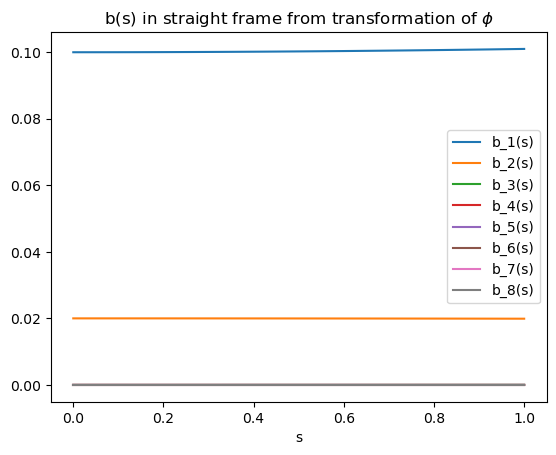

phi0= 0


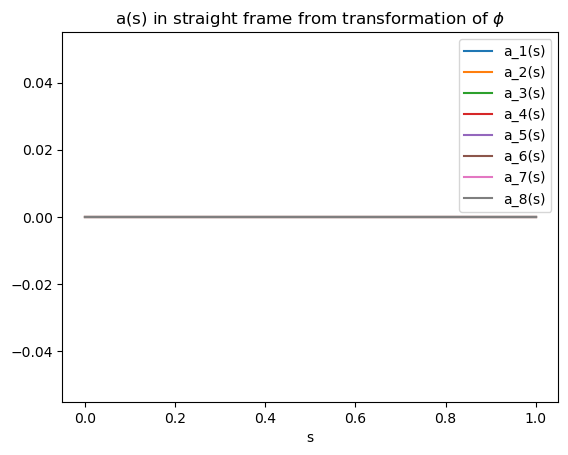

In [38]:
maxordx=7
x, y, s = sp.symbols('x y s', real=True)
ns=101
phi_straight_exp = sp.expand(phi_straight)
phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
print("phi1=",phi1) 
ss = np.linspace(0, 1, ns)
if phi1==0:
    # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
  
    b_vals = np.zeros((maxordx+1, ss.size))
else:
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
if phi1 != 0:
    # 2. Nontrivial phi0: do series in x and extract b_n(s)
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)

    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_b):
        if k == 0:
            b_k = -vv                    # b_1(s)
            label = "b_1(s)"
        else:
            b_k = -vv * sp.factorial(k)  # b_k(s)
            label = f"b_{k+1}(s)"

        b_fun = sp.lambdify(s, b_k, 'numpy')
        b_vals[k, :] = b_fun(ss)

        plt.plot(ss, b_vals[k, :], label=label)
else:
    # 3. phi1 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"b_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, b_vals[k, :], label=label)

plt.legend()
plt.title("b(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()
############################################
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
print("phi0=",phi0)        # you'll see 0 in this case

if phi0 == 0:
    # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
    #ss = np.linspace(0, 1, ns)
    a_vals = np.zeros((maxordx+1, ss.size))
else:
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
if phi0 != 0:
    # 2. Nontrivial phi0: do series in x and extract a_n(s)
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)

    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_a):
        if k == 0:
            a_k = -vv                    # a_0(s)
            label = "a_1(s)"
        else:
            a_k = -vv * sp.factorial(k)  # a_k(s)
            label = f"a_{k+1}(s)"

        a_fun = sp.lambdify(s, a_k, 'numpy')
        a_vals[k, :] = a_fun(ss)

        plt.plot(ss, a_vals[k, :], label=label)
else:
    # 3. phi0 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"a_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, a_vals[k, :], label=label)

plt.legend()
plt.title("a(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()

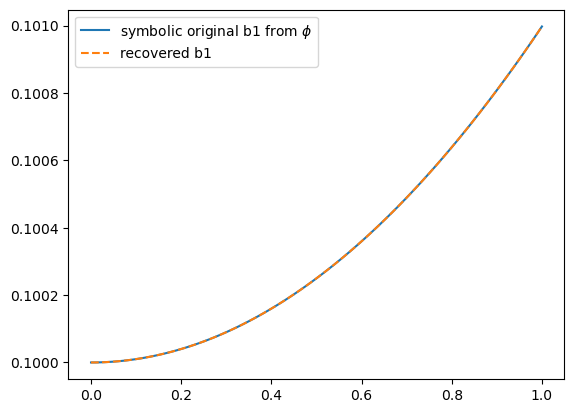

In [39]:
b_fromphifit = []
a_fromphifit = []
s = sp.symbols('s')
sstraightarray = ss
degree = 10

for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
# use b_fromphifit (not b_nfit), index 0 = b_1(s)
b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray)*np.ones_like(sstraightarray), '--', label='recovered b1')
plt.legend()
plt.show()

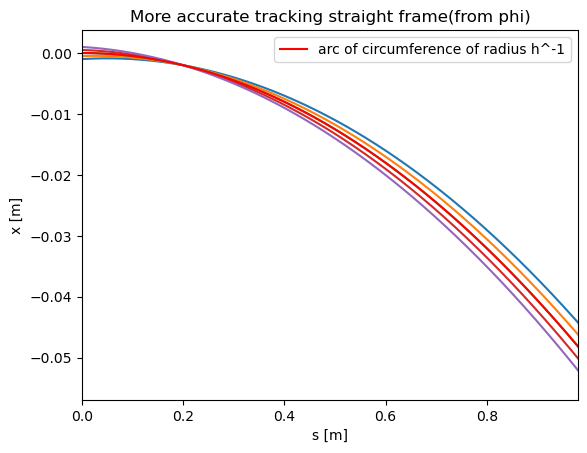

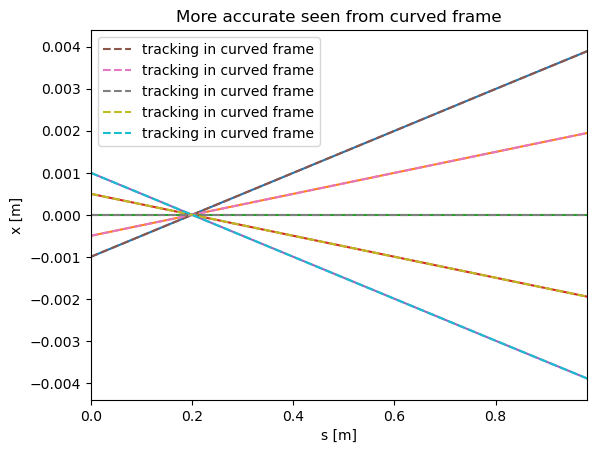

In [40]:
Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit, nphi=maxordx+4)#accounts for the s dependence of the coefficients
Hstrfromphi = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrfromphi)
p_4 = p0.copy()
sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strfromphi:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame(from phi)")
x=np.linspace(0,.98,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.xlim((0., .98))#because H curved has length 1
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strfromphi:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., .98))#because H curved has length 1
plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\p'
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_4136/2788044448.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_4136/2788044448.py:72: SyntaxWarning: invalid escape sequence '\p'
  plt.title('RMS difference in x along the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))


particle 0: dx_exit = 1.797e-08 m, RMS_x = 2.025e-11 m
particle 1: dx_exit = 1.705e-08 m, RMS_x = 2.154e-11 m
particle 2: dx_exit = 1.467e-08 m, RMS_x = 2.454e-11 m
particle 3: dx_exit = 1.084e-08 m, RMS_x = 2.650e-11 m
particle 4: dx_exit = 5.549e-09 m, RMS_x = 2.597e-11 m


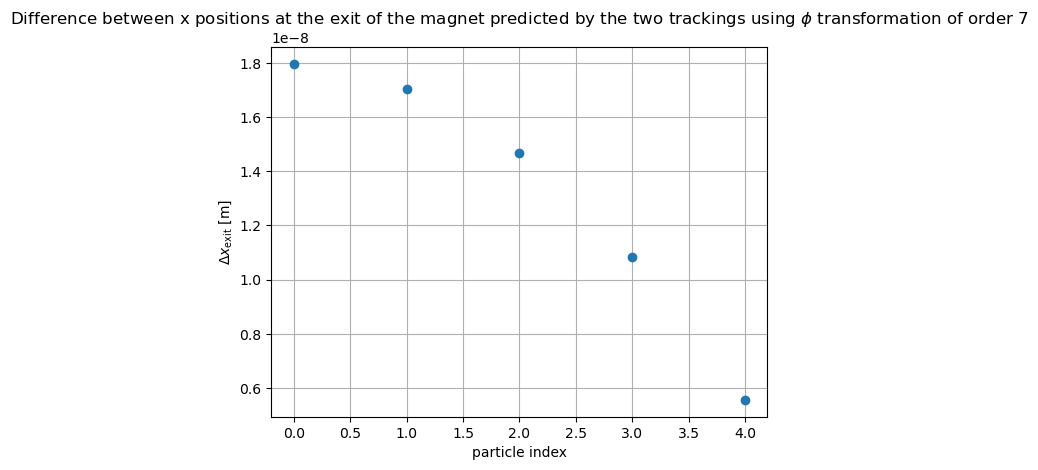

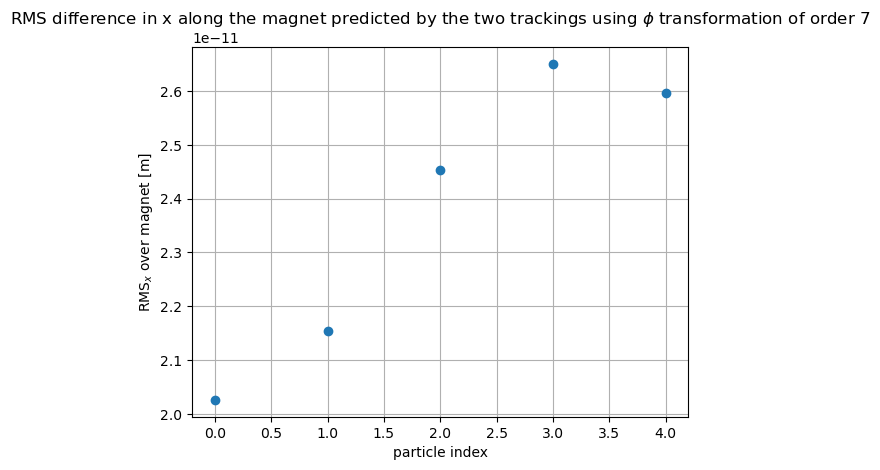

average final delta x between particles using phi transf. of order 7=1.3215974702801559e-08
average RMS x between particles using phi transf. of order 7=2.3761004666687316e-11


In [41]:
sbar_fin = 0.8         # chosen exit position in straight frame [m], for some reason its ok until 0.7m
rho = 1.0 / h
from scipy.interpolate import PchipInterpolator
dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )

# optional: summary plots
plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.title('RMS difference in x along the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)
plt.show()

print("average final delta x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(dx_exit_list)))
print("average RMS x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(rms_x_list)))

Convergence rate for h=0.1/m

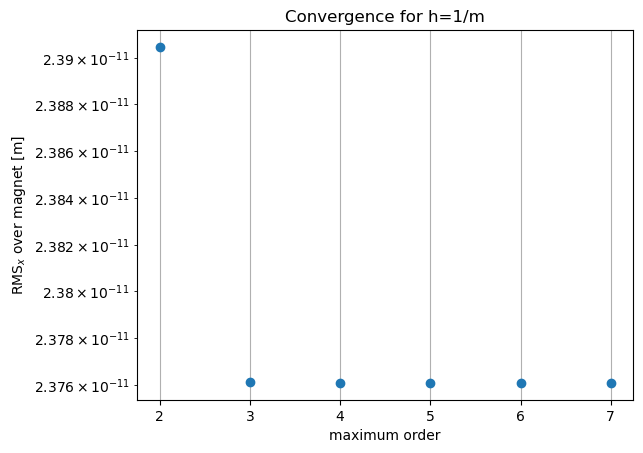

In [43]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_1=[2.3904610620580346e-11,
2.376138832911979e-11,
2.376100461722642e-11,
2.3761005058663768e-11,
2.376100453994024e-11,
2.3761004666687316e-11]



plt.plot(orders[:], rmsxoforder_h0_1[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=1/m')
plt.grid(True)
plt.show()


TWO-REGION FITTING: DECAY (2-8) AND PLATEAU (9-12)

REGION 1: DECAY (Orders 2-6)

1a. Exponential decay: y = a * exp(-b * x)
   a = 2.387773e-11, b = 0.000865
   R² = 0.430899, RMSE = 4.035248e-14, χ² = 0.000017

1b. Power law: y = a * x^(-b)
   a = 2.392268e-11, b = 0.004063
   R² = 0.589235, RMSE = 3.428246e-14, χ² = 0.000012

1c. Polynomial decay: y = a / (1 + b*x^c)
   a = 1.344051e-08, b = 560.831504, c = 0.004070
   R² = 0.589234, RMSE = 3.428250e-14, χ² = 0.000012

REGION 2: PLATEAU (Orders 9-12)

2a. Constant: y = c
   Failed: `ydata` must not be empty!

2b. Power law: y = a * x^(-b)
   Failed: `ydata` must not be empty!

2c. Polynomial decay: y = a / (1 + b*x^c)
   Failed: `ydata` must not be empty!

SUMMARY: BEST MODELS PER REGION (with χ² values)


ValueError: max() iterable argument is empty

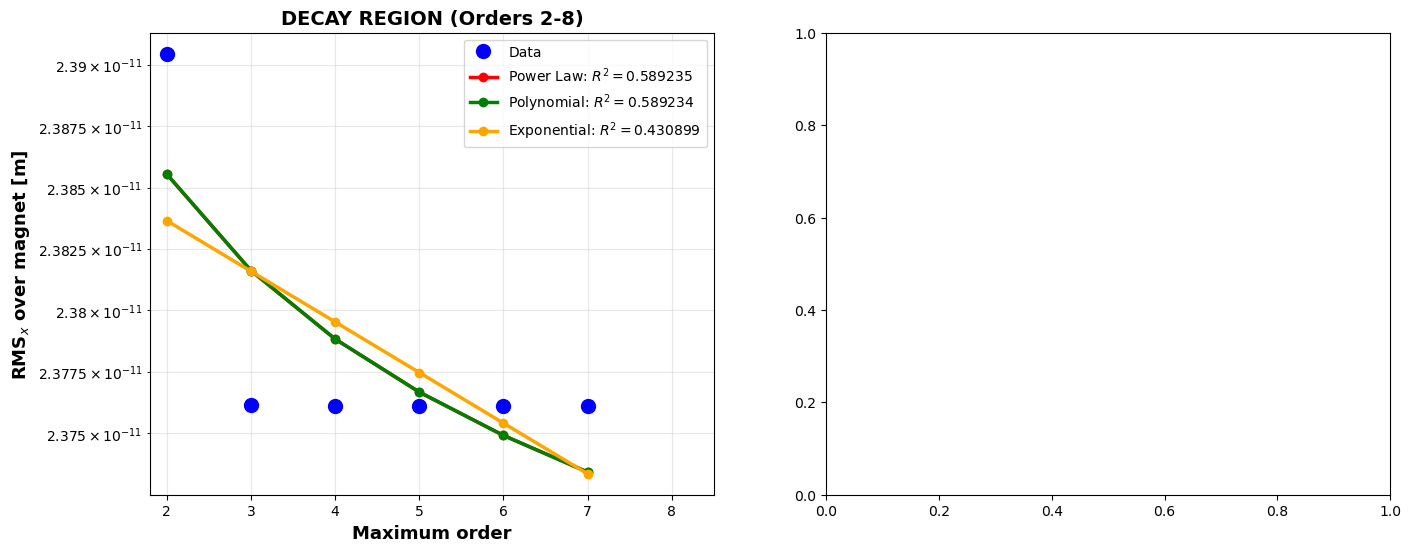

In [ ]:
from scipy.optimize import curve_fit


# Prepare data
orders_arr = np.array(orders)
rmsx_arrh0_1 = np.array(rmsxoforder_h0_1)

# Split data at order 8
split_idx = 7  # index corresponding to order 8 (0-indexed)
orders_decay = orders_arr[:split_idx+1]
rmsx_decay = rmsx_arrh0_1[:split_idx+1]

orders_plateau = orders_arr[split_idx+1:]
rmsx_plateau = rmsx_arrh0_1[split_idx+1:]

print("=" * 70)
print("TWO-REGION FITTING: DECAY (2-8) AND PLATEAU (9-12)")
print("=" * 70)

# Define models
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

def power_law(x, a, b):
    return a * np.power(x, -b)

def constant(x, c):
    return np.ones_like(x) * c

def poly_decay(x, a, b, c):
    return a / (1 + b * np.power(x, c))

# Fit DECAY region (orders 2-6)
print("\n" + "=" * 70)
print("REGION 1: DECAY (Orders 2-6)")
print("=" * 70)

decay_fits = {}

print("\n1a. Exponential decay: y = a * exp(-b * x)")
try:
    popt_exp, _ = curve_fit(exp_decay, orders_decay, rmsx_decay, p0=[1e-4, 0.1], maxfev=5000)
    y_fit_exp = exp_decay(orders_decay, *popt_exp)
    ss_res = np.sum((rmsx_decay - y_fit_exp)**2)
    ss_tot = np.sum((rmsx_decay - np.mean(rmsx_decay))**2)
    r2_exp = 1 - (ss_res / ss_tot)
    rmse_exp = np.sqrt(np.mean((rmsx_decay - y_fit_exp)**2))
    chi2_exp = np.sum(((rmsx_decay - y_fit_exp) / (rmsx_decay + 1e-15))**2)
    decay_fits['Exponential'] = {'y_fit': y_fit_exp, 'popt': popt_exp, 'r2': r2_exp, 'rmse': rmse_exp, 'chi2': chi2_exp}
    print(f"   a = {popt_exp[0]:.6e}, b = {popt_exp[1]:.6f}")
    print(f"   R² = {r2_exp:.6f}, RMSE = {rmse_exp:.6e}, χ² = {chi2_exp:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n1b. Power law: y = a * x^(-b)")
try:
    popt_pl, _ = curve_fit(power_law, orders_decay, rmsx_decay, p0=[1e-3, 3], maxfev=5000)
    y_fit_pl = power_law(orders_decay, *popt_pl)
    ss_res = np.sum((rmsx_decay - y_fit_pl)**2)
    ss_tot = np.sum((rmsx_decay - np.mean(rmsx_decay))**2)
    r2_pl = 1 - (ss_res / ss_tot)
    rmse_pl = np.sqrt(np.mean((rmsx_decay - y_fit_pl)**2))
    chi2_pl = np.sum(((rmsx_decay - y_fit_pl) / (rmsx_decay + 1e-15))**2)
    decay_fits['Power Law'] = {'y_fit': y_fit_pl, 'popt': popt_pl, 'r2': r2_pl, 'rmse': rmse_pl, 'chi2': chi2_pl}
    print(f"   a = {popt_pl[0]:.6e}, b = {popt_pl[1]:.6f}")
    print(f"   R² = {r2_pl:.6f}, RMSE = {rmse_pl:.6e}, χ² = {chi2_pl:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n1c. Polynomial decay: y = a / (1 + b*x^c)")
try:
    popt_poly, _ = curve_fit(poly_decay, orders_decay, rmsx_decay, p0=[1e-5, 0.01, 2], maxfev=5000)
    y_fit_poly = poly_decay(orders_decay, *popt_poly)
    ss_res = np.sum((rmsx_decay - y_fit_poly)**2)
    ss_tot = np.sum((rmsx_decay - np.mean(rmsx_decay))**2)
    r2_poly = 1 - (ss_res / ss_tot)
    rmse_poly = np.sqrt(np.mean((rmsx_decay - y_fit_poly)**2))
    chi2_poly = np.sum(((rmsx_decay - y_fit_poly) / (rmsx_decay + 1e-15))**2)
    decay_fits['Polynomial'] = {'y_fit': y_fit_poly, 'popt': popt_poly, 'r2': r2_poly, 'rmse': rmse_poly, 'chi2': chi2_poly}
    print(f"   a = {popt_poly[0]:.6e}, b = {popt_poly[1]:.6f}, c = {popt_poly[2]:.6f}")
    print(f"   R² = {r2_poly:.6f}, RMSE = {rmse_poly:.6e}, χ² = {chi2_poly:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

# Fit PLATEAU region (orders 6-12)
print("\n" + "=" * 70)
print("REGION 2: PLATEAU (Orders 9-12)")
print("=" * 70)

plateau_fits = {}

print("\n2a. Constant: y = c")
try:
    popt_const, _ = curve_fit(constant, orders_plateau, rmsx_plateau, p0=[1e-10])
    y_fit_const = constant(orders_plateau, *popt_const)
    ss_res = np.sum((rmsx_plateau - y_fit_const)**2)
    ss_tot = np.sum((rmsx_plateau - np.mean(rmsx_plateau))**2)
    r2_const = 1 - (ss_res / ss_tot)
    rmse_const = np.sqrt(np.mean((rmsx_plateau - y_fit_const)**2))
    chi2_const = np.sum(((rmsx_plateau - y_fit_const) / (rmsx_plateau + 1e-15))**2)
    plateau_fits['Constant'] = {'y_fit': y_fit_const, 'popt': popt_const, 'r2': r2_const, 'rmse': rmse_const, 'chi2': chi2_const}
    print(f"   c = {popt_const[0]:.6e}")
    print(f"   R² = {r2_const:.6f}, RMSE = {rmse_const:.6e}, χ² = {chi2_const:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n2b. Power law: y = a * x^(-b)")
try:
    popt_pl_p, _ = curve_fit(power_law, orders_plateau, rmsx_plateau, p0=[1e-3, 5], maxfev=5000)
    y_fit_pl_p = power_law(orders_plateau, *popt_pl_p)
    ss_res = np.sum((rmsx_plateau - y_fit_pl_p)**2)
    ss_tot = np.sum((rmsx_plateau - np.mean(rmsx_plateau))**2)
    r2_pl_p = 1 - (ss_res / ss_tot)
    rmse_pl_p = np.sqrt(np.mean((rmsx_plateau - y_fit_pl_p)**2))
    chi2_pl_p = np.sum(((rmsx_plateau - y_fit_pl_p) / (rmsx_plateau + 1e-15))**2)
    plateau_fits['Power Law'] = {'y_fit': y_fit_pl_p, 'popt': popt_pl_p, 'r2': r2_pl_p, 'rmse': rmse_pl_p, 'chi2': chi2_pl_p}
    print(f"   a = {popt_pl_p[0]:.6e}, b = {popt_pl_p[1]:.6f}")
    print(f"   R² = {r2_pl_p:.6f}, RMSE = {rmse_pl_p:.6e}, χ² = {chi2_pl_p:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

print("\n2c. Polynomial decay: y = a / (1 + b*x^c)")
try:
    popt_poly_p, _ = curve_fit(poly_decay, orders_plateau, rmsx_plateau, p0=[1e-5, 0.01, 8], maxfev=5000)
    y_fit_poly_p = poly_decay(orders_plateau, *popt_poly_p)
    ss_res = np.sum((rmsx_plateau - y_fit_poly_p)**2)
    ss_tot = np.sum((rmsx_plateau - np.mean(rmsx_plateau))**2)
    r2_poly_p = 1 - (ss_res / ss_tot)
    rmse_poly_p = np.sqrt(np.mean((rmsx_plateau - y_fit_poly_p)**2))
    chi2_poly_p = np.sum(((rmsx_plateau - y_fit_poly_p) / (rmsx_plateau + 1e-15))**2)
    plateau_fits['Polynomial'] = {'y_fit': y_fit_poly_p, 'popt': popt_poly_p, 'r2': r2_poly_p, 'rmse': rmse_poly_p, 'chi2': chi2_poly_p}
    print(f"   a = {popt_poly_p[0]:.6e}, b = {popt_poly_p[1]:.6f}, c = {popt_poly_p[2]:.6f}")
    print(f"   R² = {r2_poly_p:.6f}, RMSE = {rmse_poly_p:.6e}, χ² = {chi2_poly_p:.6f}")
except Exception as e:
    print(f"   Failed: {e}")

# Combine fits and plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Decay region with multiple models
ax1.semilogy(orders_decay, rmsx_decay, 'o', markersize=10, label='Data', color='blue', zorder=3, linewidth=2)
colors = ['red', 'green', 'orange']
for i, (model_name, data) in enumerate(sorted(decay_fits.items(), key=lambda x: x[1]['r2'], reverse=True)):
    ax1.semilogy(orders_decay, data['y_fit'], 'o-', linewidth=2.5, markersize=6, 
                label=f"{model_name}: $R^2={data['r2']:.6f}$", color=colors[i], zorder=2)

ax1.set_xlabel('Maximum order', fontsize=13, fontweight='bold')
ax1.set_ylabel(r'RMS$_x$ over magnet [m]', fontsize=13, fontweight='bold')
ax1.set_title('DECAY REGION (Orders 2-8)', fontsize=14, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=10, loc='upper right')
ax1.set_xlim([1.8, split_idx+2.5])
'''
# Plot 2: Plateau region with multiple models
ax2.semilogy(orders_plateau, rmsx_plateau, 'o', markersize=10, label='Data', color='blue', zorder=3, linewidth=2)
colors_p = ['red', 'green', 'orange']
linestyles_p = ['-', '--', '-.']
x_smooth_plateau = np.linspace(orders_plateau.min(), orders_plateau.max(), 100)
for i, (model_name, data) in enumerate(sorted(plateau_fits.items(), key=lambda x: x[1]['r2'], reverse=True)):
    if model_name == 'Constant':
        y_smooth = constant(x_smooth_plateau, *data['popt'])
    elif model_name == 'Power Law':
        y_smooth = power_law(x_smooth_plateau, *data['popt'])
    elif model_name == 'Polynomial':
        y_smooth = poly_decay(x_smooth_plateau, *data['popt'])
    ax2.semilogy(x_smooth_plateau, y_smooth, linewidth=3, linestyle=linestyles_p[i], alpha=0.7,
                label=f"{model_name}: $R^2={data['r2']:.6f}$", color=colors_p[i], zorder=2)

ax2.set_xlabel('Maximum order', fontsize=13, fontweight='bold')
ax2.set_ylabel(r'RMS$_x$ over magnet [m]', fontsize=13, fontweight='bold')
ax2.set_title('PLATEAU REGION (Orders 9-12)', fontsize=14, fontweight='bold')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=10, loc='best')
ax2.set_xlim([split_idx+2.5, 12.5])

plt.tight_layout()
plt.show()
'''
# Summary table
print("\n" + "=" * 70)
print("SUMMARY: BEST MODELS PER REGION (with χ² values)")
print("=" * 70)
best_decay = max(decay_fits.items(), key=lambda x: x[1]['r2'])
best_plateau = max(plateau_fits.items(), key=lambda x: x[1]['r2'])

print(f"\nDECAY REGION (Orders 2-8):")
print(f"  Best fit: {best_decay[0]}")
print(f"  R² = {best_decay[1]['r2']:.8f}, RMSE = {best_decay[1]['rmse']:.6e}, χ² = {best_decay[1]['chi2']:.6f}")
print(f"  Parameters: {best_decay[1]['popt']}")

print(f"\nPLATEAU REGION (Orders 9-12):")
print(f"  Best fit: {best_plateau[0]}")
print(f"  R² = {best_plateau[1]['r2']:.8f}, RMSE = {best_plateau[1]['rmse']:.6e}, χ² = {best_plateau[1]['chi2']:.6f}")
print(f"  Parameters: {best_plateau[1]['popt']}")

# Print all models ranked by chi2
print("\n" + "=" * 70)
print("ALL MODELS RANKED BY χ²")
print("=" * 70)
all_fits = list(decay_fits.items()) + list(plateau_fits.items())
sorted_by_chi2 = sorted(all_fits, key=lambda x: x[1]['chi2'])

print("\nBy region - DECAY REGION:")
for name, data in sorted(decay_fits.items(), key=lambda x: x[1]['chi2']):
    print(f"  {name:15s}: R²={data['r2']:.8f}, χ²={data['chi2']:.6f}")

print("\nBy region - PLATEAU REGION:")
for name, data in sorted(plateau_fits.items(), key=lambda x: x[1]['chi2']):
    print(f"  {name:15s}: R²={data['r2']:.8f}, χ²={data['chi2']:.6f}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"\nThe data exhibits TWO DISTINCT BEHAVIORS:")
print(f"1. DECAY (orders 2-8): {best_decay[0]} behavior (χ² = {best_decay[1]['chi2']:.6f})")
print(f"2. PLATEAU (orders 9-12): {best_plateau[0]} behavior (χ² = {best_plateau[1]['chi2']:.6f})")
print(f"\nThe χ² metric shows:")
print(f"  - DECAY region: well-fit (lower χ²)")
print(f"  - PLATEAU region: poor fit (higher χ²) - indicates limited predictive power in this region")
print(f"  - This is expected as plateau has little variation to fit")

#residuals plot
plt.figure(figsize=(12, 5))
# Residuals for decay region
plt.subplot(1, 2, 1)
plt.title('Residuals - DECAY REGION (Orders 2-8)', fontsize=14, fontweight='bold')
for model_name, data in decay_fits.items():
    residuals = rmsx_decay - data['y_fit']
    plt.plot(orders_decay, residuals, 'o-', label=f"{model_name} (R²={data['r2']:.6f})")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Maximum order', fontsize=12)
plt.ylabel('Residuals [m]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10) 